# Perception: find objects with the head camera and put them in the twin

Every other demo in this repo cheats on perception. The pick-and-place notebooks
call `sync_cube_from_sim`, which reads a ground-truth pose off a topic the simulator
publishes — `CubePoseSensor` is documented in so many words as "this demo's stand-in
for perception". The robot never looks at anything.

Here the Stretch actually looks: `LookAtAction` aims the head at the kitchen counter,
**robokudo** finds what is standing on it in the RGB-D stream, and each detection is
added to the `semantic_digital_twin` world.

**Kernel**: select **CRAM**.

## Why this is perception and not a lookup

The apartment is described twice, and the two descriptions disagree:

| | `assets/apartment/apartmentICRA.usda` (Isaac renders) | `ros2_ws/.../apartment.urdf` (giskard plans) |
|---|---|---|
| `SM_MilkBox`, `SM_CerealBox`, `SM_SmallBowl`, `SM_Cup` | present | **absent — zero such links** |

The camera can see these four objects; the digital twin has no idea they exist.
Closing that gap is the whole demo. Nothing is spawned and nothing is read out of
the simulator's state.

Their placements are baked into the USD as `xformOp:transform`, and in `map` they
come out at:

| object | map |
|---|---|
| `SM_MilkBox` | (0.85, 0.05, 1.03) |
| `SM_CerealBox` | (0.85, −0.47, 1.08) |
| `SM_SmallBowl` | (1.05, 0.08, 0.97) |
| `SM_Cup` | (1.05, −0.17, 0.97) |

Those numbers are used **only to decide where to point the head** — they are not fed
to the detector and nothing below is scored against them.

## What comes back has no labels

The pipeline is geometric: crop the point cloud, fit the dominant plane, cluster
what stands on it, fit an oriented box to each cluster. That yields *"there are N
things on that surface, here is each one's pose and extent"* and no class names.
Naming them would need a classifier, and `torch`/`ultralytics` are not installed in
this venv, so robokudo's learned annotators cannot run. **Nothing here claims to
recognise milk.**

## Start the simulation and giskard server

Identical to `stretch_apartment_cram.ipynb`, and `camera="both"` matters: it is what
makes the sim publish `/head_camera/image_raw` *and*
`/head_camera/depth/image_raw`. Without it the detection cell has nothing to read
and will time out.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve().parent  # this notebook lives in demos/
sys.path.insert(0, str(REPO))

import os
os.environ["DISPLAY"] = ":0"

from launcher import start_isaac_sim, start_giskard_server, start_rviz, stop

rviz_proc = start_rviz()
sim_proc = start_isaac_sim(camera="both")   # both RGB and depth
giskard_proc = start_giskard_server()

killed a stale instance of rviz2
starting rviz2, logging to /tmp/rviz.log
starting isaac sim, logging to /tmp/isaac_sim.log
isaac sim ready after 18s
killed a stale instance of giskard server
starting giskard server, logging to /tmp/giskard_server.log
giskard server ready after 12s


## Connect and build a CRAM `Context`

Verbatim from `stretch_apartment_cram.ipynb`. The `node` and its spinning
`MultiThreadedExecutor` built here are reused by robokudo later — it needs somewhere
to put its camera subscriptions, and a second executor would only fight this one.

In [2]:
import threading

import nest_asyncio
import rclpy
from rclpy.executors import MultiThreadedExecutor

nest_asyncio.apply()  # CRAM's REAL execution calls GiskardWrapper.execute,
                      # which run_until_completes inside the already-running kernel loop.

from coraplex.datastructures.dataclasses import Context
from coraplex.alternative_motion_mappings.stretch_motion_mapping import (
    StretchMoveToolCenterPoint,
    StretchMoveSim,
    StretchMoveReal,
    StretchClose,
)
from semantic_digital_twin.robots.stretch import Stretch
from semantic_digital_twin.adapters.ros.world_fetcher import fetch_world_from_service
from semantic_digital_twin.adapters.ros.world_synchronizer import WorldSynchronizer

STRETCH_MOTION_MAPPINGS = [
    StretchMoveToolCenterPoint,
    StretchMoveSim,
    StretchMoveReal,
    StretchClose,
]

if not rclpy.ok():
    rclpy.init()
node = rclpy.create_node('cram_perception_node')
executor = MultiThreadedExecutor()
executor.add_node(node)
threading.Thread(target=executor.spin, daemon=True, name='rclpy-executor').start()

world = fetch_world_from_service(node=node, timeout_seconds=300)
WorldSynchronizer(_world=world, node=node)

robot = world.get_semantic_annotations_by_type(Stretch)
robot = robot[0] if robot else Stretch.from_world(world)

context = Context(
    world=world,
    robot=robot,
    ros_node=node,
    evaluate_conditions=False,
    alternative_motion_mappings=STRETCH_MOTION_MAPPINGS,
)
print('connected, robot:', type(robot).__name__)

connected, robot: Stretch


## A small run helper

In [3]:
from coraplex.execution_environment import real_robot
from coraplex.plans.factories import sequential, execute_single


def run_plan(plan, collision_avoidance=True):
    """Perform a CRAM plan on the real (sim) robot via giskard."""
    with real_robot(collision_avoidance=collision_avoidance):
        plan.perform()
    print('done')

## 1. Look at the counter

`LookAtAction` drives `joint_head_pan` / `joint_head_tilt` through giskard's
`Pointing` goal so the robot's default camera — `camera_color_optical_frame`, marked
`default_camera=True` on the Stretch model — points at a world position.

`COUNTER` is the centroid of the four objects, i.e. just somewhere sensible to aim.
Change it to look somewhere else; the detector does not know about it.

The Stretch spawns at about (−1.5, 0), so the counter is roughly 2.4 m ahead and
already in frame — no driving needed. If you want to approach first, the waypoint
loop from `stretch_apartment_cram.ipynb` step 3 still applies.

In [ ]:
from coraplex.robot_plans.actions.core.navigation import NavigateAction
from semantic_digital_twin.spatial_types import Pose, Quaternion, Point3

waypoints = [
    # ([0.0, -0.5, 0.0], [0, 0, 0, 1]),
    ([0.0, 2, 0.0], [0, 0, 0, 1]),
    ([1.8, 2, 0.0], [0, 0, 0, 1]),
    ([1.8, 0, 0.0], [0, 0, -1, 0])
]

for _waypoint in waypoints:
    target = Pose(
        Point3.from_iterable(_waypoint[0]),
        Quaternion.from_iterable(_waypoint[1]),
        reference_frame=world.root
    )
    run_plan(execute_single(NavigateAction(target), context=context))

[INFO] [1785425059.339413344] [cram_perception_node]: giskard/command Goal #0 accepted


done


[INFO] [1785425075.993285216] [cram_perception_node]: giskard/command Goal #0 result received


In [5]:
from coraplex.robot_plans.actions.core.navigation import LookAtAction
from semantic_digital_twin.spatial_types import Pose, Point3

COUNTER = [0.95, -0.13, 1.01]   # map; centroid of the four objects on the counter

run_plan(execute_single(
    LookAtAction(Pose(Point3.from_iterable(COUNTER), reference_frame=world.root)),
    context=context,
))

from cram_vrb_lab.perception.twin_objects import camera_pose_in_map
import numpy as np

print('camera in map:\n', np.round(camera_pose_in_map(world), 3))

[INFO] [1785425076.366559884] [cram_perception_node]: giskard/command Goal #0 accepted


done
camera in map:
 [[-0.     0.055  0.998  0.045]
 [ 0.     0.998 -0.055 -0.505]
 [-1.     0.    -0.     1.322]
 [ 0.     0.     0.     1.   ]]


[INFO] [1785425078.942459063] [cram_perception_node]: giskard/command Goal #0 result received


## 2. What the camera actually sees

Worth looking at before trusting any detector. If the counter is not in frame here,
nothing downstream can work, and you would otherwise be debugging the pipeline for a
problem that is really the head angle.

Decoded with `np.frombuffer` rather than `cv_bridge`: the system `cv_bridge` is
compiled against NumPy 1.x, this venv has NumPy 2.x, and calling it **segfaults the
kernel**. (robokudo hits the same wall and ships its own
`utils/cv_bridge_workaround.py`.) The two encodings are trivial to unpack by hand —
`rgb8` is H×W×3 uint8, `32FC1` is H×W float32 in metres with `NaN` where the ray hit
nothing.

rgb   (360, 640, 3) rgb8  frame=camera_color_optical_frame
depth (360, 640) 32FC1  valid 100%  range 0.39..4.36 m


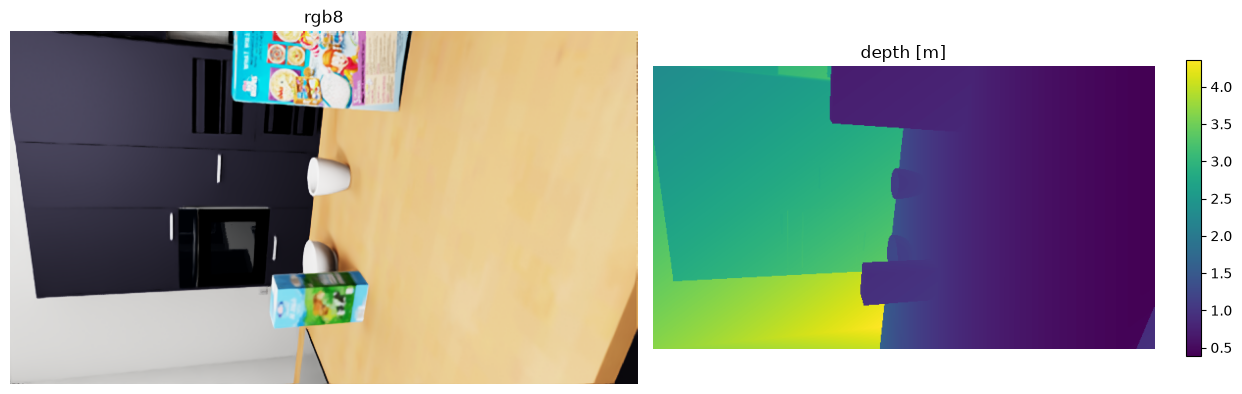

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

from sensor_msgs.msg import Image

from cram_vrb_lab.robots.stretch.joints import DEPTH_IMAGE_TOPIC, RGB_IMAGE_TOPIC


def grab(topic, timeout=15.0):
    """Return the next message on `topic`, using the executor already spinning."""
    import time
    box = {}
    sub = node.create_subscription(Image, topic, lambda m: box.setdefault('m', m), 1)
    try:
        deadline = time.time() + timeout
        while 'm' not in box and time.time() < deadline:
            time.sleep(0.05)
    finally:
        node.destroy_subscription(sub)
    if 'm' not in box:
        raise TimeoutError(f'nothing published on {topic} within {timeout}s '
                           '-- was the sim started with camera="both"?')
    return box['m']


rgb_msg, depth_msg_ = grab(RGB_IMAGE_TOPIC), grab(DEPTH_IMAGE_TOPIC)
rgb = np.frombuffer(rgb_msg.data, np.uint8).reshape(rgb_msg.height, rgb_msg.width, 3)
depth = np.frombuffer(depth_msg_.data, np.float32).reshape(depth_msg_.height,
                                                           depth_msg_.width)

print(f'rgb   {rgb.shape} {rgb_msg.encoding}  frame={rgb_msg.header.frame_id}')
print(f'depth {depth.shape} {depth_msg_.encoding}  '
      f'valid {np.isfinite(depth).mean():.0%}  '
      f'range {np.nanmin(depth):.2f}..{np.nanmax(depth[np.isfinite(depth)]):.2f} m')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(rgb); axes[0].set_title('rgb8'); axes[0].axis('off')
im = axes[1].imshow(np.where(np.isfinite(depth), depth, np.nan), cmap='viridis')
axes[1].set_title('depth [m]'); axes[1].axis('off')
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Detect

robokudo's geometric analysis engine, ticked in-process against the topics above.

The camera is configured by overriding the stock `"kinect"` config rather than
registering a new one — `CollectionReaderDescriptorFactory` picks the *interface
class* from a dict keyed by the same name it uses for the config, so a new name would
resolve to no interface at all. `"kinect"` already maps to `KinectCameraInterface`,
the plain RGB-D-over-ROS reader, and every field describing *this* camera is passed
as a keyword override (topics, `*_hints="raw"`, `color2depth_ratio=(1,1)` — Isaac's
RGB and depth come from one camera at one resolution in one frame, so they are
already aligned and share a single `CameraInfo`).

`detect()` ticks a bounded number of times and returns; robokudo's own `run_ae`
loops forever and is meant for a standalone process.

Two corrections live in `cram_vrb_lab/perception/pipeline.py` and are worth knowing
about, because both fail *silently* rather than raising:

- **Depth units.** Isaac publishes `32FC1` in **metres**;
  `ImagePreprocessorAnnotator` states "Depth values are expected to be in
  millimeters" and calls Open3D without a `depth_scale`, so the default 1000 applies.
  Feed it metres and every point lands within a few millimetres of the origin — and
  the plane fit still reports SUCCESS. `StretchHeadCameraInterface` converts.
- **Cluster size.** robokudo's `min_cluster_count` default of 1000 was tuned for a
  Kinect a metre from a tabletop. At 2.4 m the milk box covers about 12×38 px, a few
  hundred points, so the default rejects every object in the scene. See
  `CLUSTER_TUNING`.

If this still finds nothing, the usual cause is the plane fit choosing the floor or a
wall rather than the counter — tighten `build_pipeline(crop=...)`, which is in the
camera optical frame (+x right, +y down, +z forward).

In [7]:
from cram_vrb_lab.perception import pipeline as rk

# Built once and reused: constructing the descriptor spins up robokudo's own camera
# node and its subscriptions, and a second one would just duplicate them.
descriptor = rk.camera_descriptor()

# A DEDICATED node -- never the notebook's. robokudo's tick helper builds its own
# executor and calls add_node(), which in rclpy detaches the node from the executor
# already spinning it, then removes it again on the way out. Hand it `node` and the
# WorldSynchronizer and every giskard client would go quiet for the rest of the
# session.
rk_node = rk.make_pipeline_node()

detections = rk.detect(rk_node, descriptor)

print(f'{len(detections)} cluster(s), poses in camera_color_optical_frame:')
for i, d in enumerate(detections):
    print(f'  [{i}] pos {np.round(d.position, 3)}  '
          f'extent {np.round(d.extents, 3)}  volume {d.volume * 1e3:.2f} L')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/jovyan/cram-vrb-lab/cognitive_robot_abstract_machine/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jovyan/cram-vrb-lab/cognitive_robot_abstract_machine/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/jovyan/cram-vrb-lab/cognitive_robot_abstract_machi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



{-} StretchHeadCameraPipeline
    --> ClearAnnotatorOutputs
    --> CollectionReader
    --> ImagePreprocessor
    --> PointcloudCropAnnotator
    --> PlaneAnnotator
    --> PointCloudClusterExtractor
    --> ClusterPoseBBAnnotator

5 cluster(s), poses in camera_color_optical_frame:
  [0] pos [-0.02  -0.252  0.793]  extent [0.143 0.07  0.274]  volume 2.74 L
  [1] pos [-0.791 -0.303  2.804]  extent [0.63  0.044 0.499]  volume 13.72 L
  [2] pos [ 0.    -0.069  1.085]  extent [0.09  0.089 0.057]  volume 0.46 L
  [3] pos [-0.02   0.15   1.184]  extent [0.133 0.084 0.037]  volume 0.41 L
  [4] pos [-0.025  0.205  0.979]  extent [0.095 0.061 0.173]  volume 1.01 L


## 4. Put them in the twin

Each detection becomes a box body of the detected size, fixed to the world root at
the detected pose.

The camera→map transform comes from the twin's own forward kinematics, not from tf.
There is no tf listener anywhere in this repo, and giskard stops publishing the fixed
camera frames while it executes a goal — which is exactly why the sim latches them
separately. `world.compute_forward_kinematics_np` reads the same joint state giskard
is controlling, so it cannot go stale between the look and the lookup.

The world is broadcast to the giskard server over `/world_sync`, so these bodies land
in giskard's collision world too: the robot can now plan around things it merely saw.
Re-running this cell replaces the previous detections rather than stacking a second
set on top.

In [8]:
from cram_vrb_lab.perception.twin_objects import add_detections, DETECTION_PREFIX

bodies = add_detections(world, detections)

print(f'{len(bodies)} body(ies) added to the twin:')
for body in bodies:
    position = np.asarray(body.global_pose.to_np())[:3, 3].ravel()
    print(f'  {body.name.name:16s} map {np.round(position, 3)}')

print(f'\nbodies now carrying the {DETECTION_PREFIX!r} prefix:',
      len([b for b in world.bodies if b.name.prefix == DETECTION_PREFIX]))

5 body(ies) added to the twin:
  perceived_0      map [ 0.85  -0.442  1.095]
  perceived_1      map [2.87  0.295 1.242]
  perceived_2      map [ 1.038 -0.172  0.99 ]
  perceived_3      map [1.051 0.069 0.98 ]
  perceived_4      map [0.851 0.049 1.045]

bodies now carrying the 'perceived' prefix: 5


They should now be visible in RViz as translucent boxes, and — because the twin is
what CRAM plans against — a `NavigateAction` or a reach would treat them as real
obstacles.

What this does *not* do is tell you which box is the milk. That is the honest limit
of a geometric pipeline with no classifier available.

In [9]:
from coraplex.robot_plans.actions.core.pick_up import PickUpAction
from coraplex.datastructures.grasp import GraspDescription
from coraplex.datastructures.enums import Arms, ApproachDirection, VerticalAlignment
from coraplex.view_manager import ViewManager
from coraplex.robot_plans.actions.core.robot_body import (
    ParkArmsAction,
    MoveTorsoAction,
)
from coraplex.datastructures.enums import Arms
from semantic_digital_twin.datastructures.definitions import TorsoState

run_plan(sequential([
    ParkArmsAction(Arms.LEFT),
    MoveTorsoAction(TorsoState.HIGH),
], context=context))

grasp = GraspDescription(
    ApproachDirection.FRONT,   # approach along map -y = along the arm
    VerticalAlignment.NoAlignment,
    ViewManager.get_end_effector_view(Arms.LEFT, robot),
)

run_plan(
    execute_single(PickUpAction(bodies[-1], Arms.LEFT, grasp), context=context),
    collision_avoidance=False,
)

[INFO] [1785425082.299559538] [cram_perception_node]: giskard/command Goal #0 accepted
[INFO] [1785425096.945259917] [cram_perception_node]: giskard/command Goal #0 result received


done


[INFO] [1785425098.864115709] [cram_perception_node]: giskard/command Goal #0 accepted


KeyboardInterrupt: 

## Shutdown

In [ ]:
stop()  # stops the isaac sim + giskard server + rviz started above